In [80]:
import os
import pandas as pd
import geopandas as gpd
import rasterio
import re
import numpy as np
import matplotlib.pyplot as plt

In [81]:
# user-defined paths
base_dir = '../../../../datos-notebooks/3.global-data-cba/'
ground_data_name = 'ground_data_170226_shadow_sun.csv'

In [82]:
# derived paths
ground_data_path = os.path.join(base_dir, 'MRT-prediction/ground_data', ground_data_name)

#### reading file

In [83]:
df = pd.read_csv(ground_data_path, sep=",")

In [84]:
df

,time,instrument (1 viejo 2 nuevo),TA (a),TA (t),TG,condition,wind,obs 1,obs 2
0,12:04,2,NaN,26.5,30.5,sun,NaN,en mano,NaN
1,12:04,1,NaN,26.5,35.4,shadow,NaN,en mano,NaN
2,12:05,2,NaN,26.5,32.5,sun,NaN,en mano,NaN
3,12:05,2,NaN,26.5,33.6,shadow,NaN,en mano,NaN
4,12:06,2,NaN,27.5,34.8,sun,NaN,en mano,NaN
5,12:08,2,26.1,27.9,37.6,sun,0.0,sobre caja negra,NaN
6,12:09,1,26.5,29.8,31.8,shadow,0.3,silleta negra,NaN
7,12:09,2,26.7,28.8,39.2,sun,0.0,caja negra,NaN
8,12:10,1,27.0,29.3,29.9,shadow,0.5,silleta negra,NaN
9,12:10,2,27.6,29.2,40.2,sun,0.0,caja negra,NaN


#### correcting t1 values
TG1_corr = 0.639 * TG1 + 9.681 from notebook 3.4.4.1.

TG1: Old thermometer (Sper Scientific 800036)

TG2: new thermometer (TM-188D TENMARS )

In [85]:
# Create corrected TG column based on instrument used
df["tg_corr"] = np.where(
    df["instrument (1 viejo 2 nuevo)"] == 1,
    0.639 * df["TG"] + 9.681,   # apply correction for old instrument
    df["TG"]                   # keep original value for new instrument
)



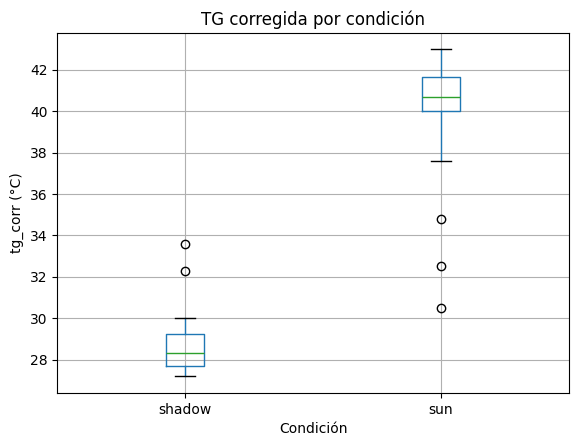

In [86]:
import matplotlib.pyplot as plt

# Boxplot of corrected TG by condition
df.boxplot(column="tg_corr", by="condition")

plt.title("TG corregida por condición")
plt.suptitle("")  # remove automatic subtitle
plt.xlabel("Condición")
plt.ylabel("tg_corr (°C)")
plt.show()

In [87]:
import plotly.express as px
import pandas as pd

# Convert time to datetime
df["time"] = pd.to_datetime(df["time"], format="%H:%M")

fig = px.scatter(
    df,
    x="time",
    y="tg_corr",
    color="condition",
    color_discrete_map={
        "sun": "orange",
        "shadow": "blue"
    },
    hover_data=["TG", "tg_corr", "wind"],
    title="TG in time (corrected)"
)

fig.show()

MRT

In [ ]:
# Fill NaN values
df["TA (t)"] = df["TA (t)"].fillna(29.5)
df["wind"] = df["wind"].fillna(0.00)

# Wind was measured with 2nd anemometer (big one) - corrections are made based on notebook 3.4.4.2.
# Subtract 0.88 for wind extracted with anemometer 2 (big one)
df["wind_corr"] = df["wind"] - 0.88
df["wind_corr"] = np.where(df["wind_corr"] <= 0, 0.01, df["wind_corr"]) # set minimum 0.01 to avoid issues

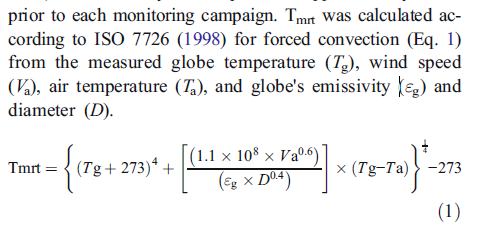

In [89]:
# Parameters
eps = 0.95
D1 = 0.04   # diameter of globe 1 [m] 
D2 = 0.05  # diameter of globe 2 [m] 

# Select diameter according to instrument
D = np.where(df["instrument (1 viejo 2 nuevo)"] == 1, D1,D2)

# MRT calculation using row-specific diameter
# wind used close to 0 for all cases because values were introducing errors and the changes are not significant (all under 1 m/s)
df["MRT"] = (
    (
        (df["tg_corr"] + 273.15)**4
        + (1.1e8 * df["wind_corr"]  **0.6 / (eps * D**0.4)) * (df["tg_corr"] - df["TA (t)"]) 
    )**0.25
    - 273.15
)

In [90]:
import plotly.express as px
import pandas as pd


fig = px.scatter(
    df,
    x="time",
    y="MRT",
    color="condition",
    color_discrete_map={
        "sun": "orange",
        "shadow": "blue"
    },
    hover_data=["TG", "MRT", "wind"],
    title="MRT in time "
)

fig.show()

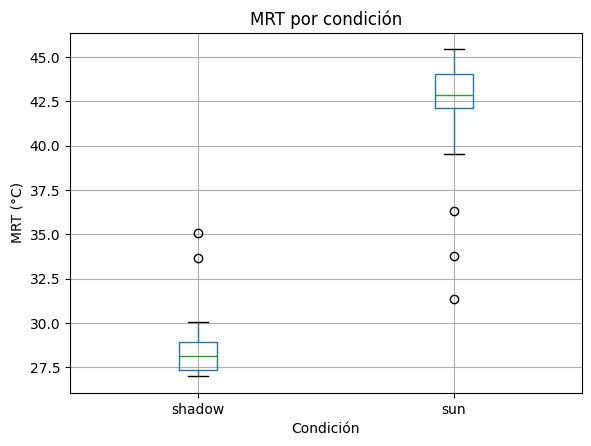

In [91]:
import matplotlib.pyplot as plt

# Boxplot of corrected MRT by condition
df.boxplot(column="MRT", by="condition")

plt.title("MRT por condición")
plt.suptitle("")  # remove automatic subtitle
plt.xlabel("Condición")
plt.ylabel("MRT (°C)")
plt.show()


In [92]:
df_filtrado = df[df["time"] >= pd.to_datetime("12:09", format="%H:%M")]

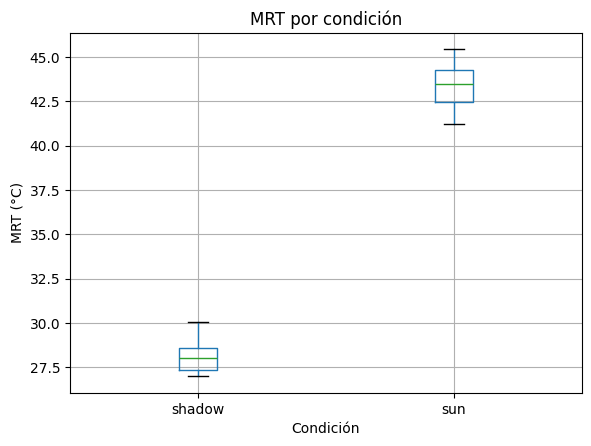

In [93]:
# Boxplot of corrected and filtered MRT by condition
df_filtrado.boxplot(column="MRT", by="condition")

plt.title("MRT por condición")
plt.suptitle("")  # remove automatic subtitle
plt.xlabel("Condición")
plt.ylabel("MRT (°C)")
plt.show()

In [94]:
# Compute mean by condition
means = df_filtrado.groupby("condition")["MRT"].mean()

# Difference sun - shadow
diff = means["sun"] - means["shadow"]
diff = round(diff, 2)

means, diff

(condition
 shadow    28.061106
 sun       43.373919
 Name: MRT, dtype: float64,
 np.float64(15.31))

In [95]:
from scipy.stats import ttest_ind

sun = df_filtrado[df_filtrado["condition"] == "sun"]["MRT"]
shadow = df_filtrado[df_filtrado["condition"] == "shadow"]["MRT"]

ttest_ind(sun, shadow, equal_var=False)  # Welch t-test

TtestResult(statistic=np.float64(42.832203550372775), pvalue=np.float64(6.141667586899096e-29), df=np.float64(30.687622985954484))

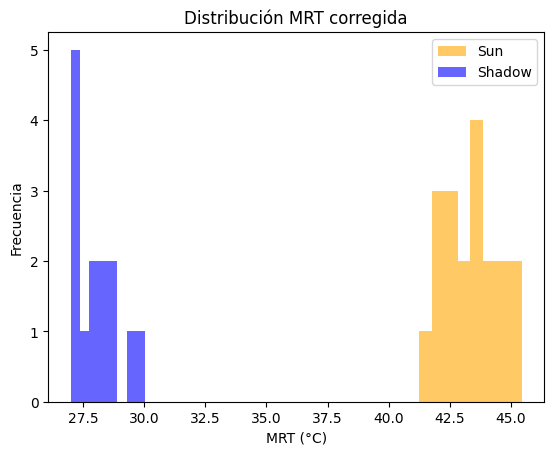

In [96]:
import matplotlib.pyplot as plt

sun = df_filtrado[df_filtrado["condition"] == "sun"]["MRT"]
shadow = df_filtrado[df_filtrado["condition"] == "shadow"]["MRT"]

plt.hist(sun, bins=8, alpha=0.6, label="Sun", color="orange")
plt.hist(shadow, bins=8, alpha=0.6, label="Shadow", color="blue")

plt.xlabel("MRT (°C)")
plt.ylabel("Frecuencia")
plt.title("Distribución MRT corregida")
plt.legend()
plt.show()